In [11]:
import pandas as pd

In [12]:
df = pd.read_csv("Iris.csv")

In [13]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [25]:
print(df.shape[0])

150


In [26]:
print(df.columns)
print(list(df.columns))

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [38]:
print("열별 null 개수:")
print(df.isnull().sum())
print("전체 null 개수:", df.isnull().sum().sum())

num_df = df.select_dtypes(include="number")
print("숫자 열 개수:", num_df.shape[1])
print("숫자 열 이름:", list(num_df.columns))

열별 null 개수:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
전체 null 개수: 0
숫자 열 개수: 5
숫자 열 이름: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [39]:
df.isna().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [52]:
print("꽃받침 길이 평균:", df["SepalLengthCm"].mean())

print("꽃잎 너비 최댓값:", df["PetalWidthCm"].max())

꽃받침 길이 평균: 5.843333333333334
꽃잎 너비 최댓값: 2.5


In [53]:
cnt = df["Species"].value_counts()
print(cnt)
print("세 종류의 개수가 같나요?", cnt.nunique() == 1)
print(cnt.reset_index().rename(columns={"index": "species", "Species": "count"}))

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64
세 종류의 개수가 같나요? True
             count  count
0      Iris-setosa     50
1  Iris-versicolor     50
2   Iris-virginica     50


In [54]:
petal_len_gt_2 = df[df["PetalLengthCm"] > 2.0]
print("꽃잎 길이 > 2.0 개수:", petal_len_gt_2.shape[0])

sepal_w_gt_35 = df[df["SepalWidthCm"] > 3.5]
print("꽃받침 너비 > 3.5 데이터 개수:", sepal_w_gt_35.shape[0])
print(sepal_w_gt_35)

꽃잎 길이 > 2.0 개수: 100
꽃받침 너비 > 3.5 데이터 개수: 18
      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
4      5            5.0           3.6            1.4           0.2   
5      6            5.4           3.9            1.7           0.4   
10    11            5.4           3.7            1.5           0.2   
14    15            5.8           4.0            1.2           0.2   
15    16            5.7           4.4            1.5           0.4   
16    17            5.4           3.9            1.3           0.4   
18    19            5.7           3.8            1.7           0.3   
19    20            5.1           3.8            1.5           0.3   
21    22            5.1           3.7            1.5           0.4   
22    23            4.6           3.6            1.0           0.2   
32    33            5.2           4.1            1.5           0.1   
33    34            5.5           4.2            1.4           0.2   
44    45            5.1           3.8         

In [45]:

versi = df[df["Species"] == "Iris-versicolor"]
print("Iris-versicolor 평균 꽃잎 길이:", versi["PetalLengthCm"].mean())

virg = df[df["Species"] == "Iris-virginica"]
print("Iris-virginica 최대 꽃받침 너비:", virg["SepalWidthCm"].max())

Iris-versicolor 평균 꽃잎 길이: 4.26
Iris-virginica 최대 꽃받침 너비: 3.8


In [47]:
# 문제 12) 종류별 평균 비교하기

# 종류별 평균(꽃받침 길이, 꽃잎 너비) 계산
mean_tbl = (
    df.groupby("Species")[["SepalLengthCm", "PetalWidthCm"]]
      .mean()
      .rename(columns={"SepalLengthCm": "mean_sepal_length",
                       "PetalWidthCm": "mean_petal_width"})
)

print("종류별 평균 표")
print(mean_tbl)

# 1) 평균 꽃받침 길이가 가장 긴 종류
longest_sepal_species = mean_tbl["mean_sepal_length"].idxmax()
print("\n평균 꽃받침이 가장 긴 종류:", longest_sepal_species)

# 2) 평균 꽃잎 너비가 가장 넓은 종류
widest_petal_species = mean_tbl["mean_petal_width"].idxmax()
print("평균 꽃잎이 가장 넓은 종류:", widest_petal_species)

# (선택) 보기 좋게 정렬해서 표로 출력
print("\n꽃받침 길이 내림차순 정렬")
print(mean_tbl.sort_values("mean_sepal_length", ascending=False))

print("\n꽃잎 너비 내림차순 정렬")
print(mean_tbl.sort_values("mean_petal_width", ascending=False))

종류별 평균 표
                 mean_sepal_length  mean_petal_width
Species                                             
Iris-setosa                  5.006             0.244
Iris-versicolor              5.936             1.326
Iris-virginica               6.588             2.026

평균 꽃받침이 가장 긴 종류: Iris-virginica
평균 꽃잎이 가장 넓은 종류: Iris-virginica

꽃받침 길이 내림차순 정렬
                 mean_sepal_length  mean_petal_width
Species                                             
Iris-virginica               6.588             2.026
Iris-versicolor              5.936             1.326
Iris-setosa                  5.006             0.244

꽃잎 너비 내림차순 정렬
                 mean_sepal_length  mean_petal_width
Species                                             
Iris-virginica               6.588             2.026
Iris-versicolor              5.936             1.326
Iris-setosa                  5.006             0.244


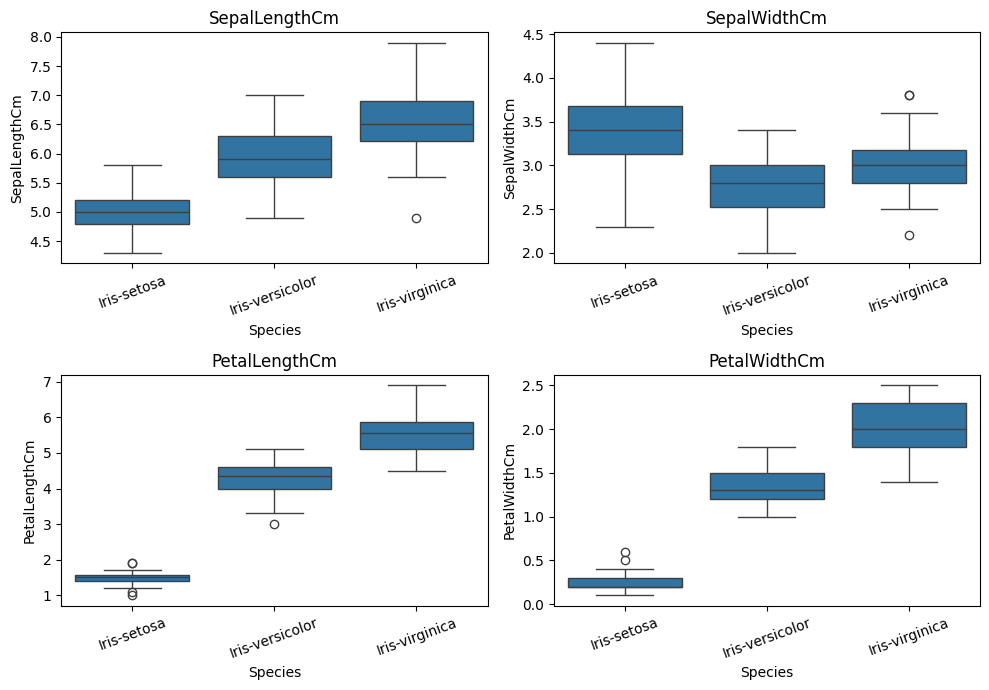


[변수별 '가장 넓은 범위' 1등(IQR 기준)]
      feature widest_species_by_IQR  IQR(Q3-Q1)
PetalLengthCm        Iris-virginica       0.775
 PetalWidthCm        Iris-virginica       0.500
SepalLengthCm       Iris-versicolor       0.700
 SepalWidthCm           Iris-setosa       0.550

[변수별 '가장 넓은 범위' 1등(전체 range 기준, 참고)]
      feature widest_species_by_range  range(max-min)
PetalLengthCm          Iris-virginica             2.4
 PetalWidthCm          Iris-virginica             1.1
SepalLengthCm          Iris-virginica             3.0
 SepalWidthCm             Iris-setosa             2.1

[이상치(점) 존재 여부 요약]
      feature  total_outliers  has_outliers?
PetalLengthCm               5           True
 PetalWidthCm               2           True
SepalLengthCm               1           True
 SepalWidthCm               3           True

[종류/변수별 상세 표]
      feature         species  IQR(Q3-Q1)  range(max-min)  outlier_count(1.5*IQR)
PetalLengthCm  Iris-virginica       0.775             2.4                       0


In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

# --- 1) 박스플롯(4개 변수) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for ax, col in zip(axes, features):
    sns.boxplot(data=df, x="Species", y=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# --- 2) "가장 넓은 범위"와 이상치 여부를 표로 정리 ---
rows = []
for col in features:
    # species별 Q1/Q3/IQR
    q = (df.groupby("Species")[col]
           .quantile([0.25, 0.75])
           .unstack()
           .rename(columns={0.25:"q1", 0.75:"q3"}))
    q["IQR"] = q["q3"] - q["q1"]

    # species별 전체 범위(참고용: max-min)
    r = df.groupby("Species")[col].agg(min="min", max="max")
    r["range"] = r["max"] - r["min"]

    # 이상치(1.5*IQR rule) 개수
    bounds = q.copy()
    bounds["lower"] = bounds["q1"] - 1.5 * bounds["IQR"]
    bounds["upper"] = bounds["q3"] + 1.5 * bounds["IQR"]

    tmp = df[["Species", col]].merge(bounds[["lower","upper"]], left_on="Species", right_index=True)
    out = tmp[(tmp[col] < tmp["lower"]) | (tmp[col] > tmp["upper"])]

    for sp in q.index:
        rows.append({
            "feature": col,
            "species": sp,
            "IQR(Q3-Q1)": q.loc[sp, "IQR"],
            "range(max-min)": r.loc[sp, "range"],
            "outlier_count(1.5*IQR)": int((out["Species"] == sp).sum())
        })

result = pd.DataFrame(rows)

# 변수별로 IQR이 가장 큰 species(=박스플롯에서 가장 '넓은' 박스)
winners_iqr = (result.sort_values(["feature","IQR(Q3-Q1)"], ascending=[True, False])
                     .groupby("feature").head(1)[["feature","species","IQR(Q3-Q1)"]]
                     .rename(columns={"species":"widest_species_by_IQR"}))

# 변수별로 전체 range가 가장 큰 species(참고)
winners_range = (result.sort_values(["feature","range(max-min)"], ascending=[True, False])
                       .groupby("feature").head(1)[["feature","species","range(max-min)"]]
                       .rename(columns={"species":"widest_species_by_range"}))

# 변수별 이상치 요약(있/없)
outlier_summary = (result.groupby("feature")["outlier_count(1.5*IQR)"]
                         .sum()
                         .reset_index()
                         .rename(columns={"outlier_count(1.5*IQR)":"total_outliers"}))
outlier_summary["has_outliers?"] = outlier_summary["total_outliers"] > 0

print("\n[변수별 '가장 넓은 범위' 1등(IQR 기준)]")
print(winners_iqr.to_string(index=False))

print("\n[변수별 '가장 넓은 범위' 1등(전체 range 기준, 참고)]")
print(winners_range.to_string(index=False))

print("\n[이상치(점) 존재 여부 요약]")
print(outlier_summary.to_string(index=False))

print("\n[종류/변수별 상세 표]")
print(result.sort_values(["feature","IQR(Q3-Q1)"], ascending=[True, False]).to_string(index=False))

In [50]:
import pandas as pd

# 1) 새로운 값(면적) 계산
df = df.copy()
df["sepal_area"] = df["SepalLengthCm"] * df["SepalWidthCm"]
df["petal_area"] = df["PetalLengthCm"] * df["PetalWidthCm"]

# 2) 종류별 평균 면적 표 만들기
area_mean = (
    df.groupby("Species")[["sepal_area", "petal_area"]]
      .mean()
      .rename(columns={"sepal_area": "mean_sepal_area",
                       "petal_area": "mean_petal_area"})
)

print("종류별 평균 면적 표")
print(area_mean)

# 3) 가장 큰 종류 찾기
largest_sepal_area_species = area_mean["mean_sepal_area"].idxmax()
largest_petal_area_species = area_mean["mean_petal_area"].idxmax()

print("\n평균 꽃받침 면적이 가장 큰 종류:", largest_sepal_area_species)
print("평균 꽃잎 면적이 가장 큰 종류:", largest_petal_area_species)

종류별 평균 면적 표
                 mean_sepal_area  mean_petal_area
Species                                          
Iris-setosa              17.2088           0.3628
Iris-versicolor          16.5262           5.7204
Iris-virginica           19.6846          11.2962

평균 꽃받침 면적이 가장 큰 종류: Iris-virginica
평균 꽃잎 면적이 가장 큰 종류: Iris-virginica


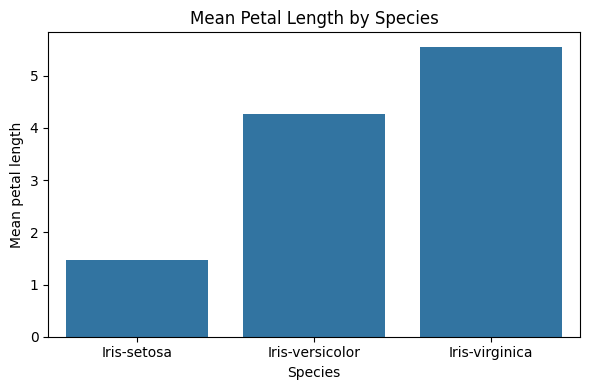

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="Species",
    y="PetalLengthCm",
    estimator="mean",
    errorbar=None
)

plt.title("Mean Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Mean petal length")
plt.tight_layout()
plt.show()

In [67]:
import matplotlib.pyplot as plt


In [72]:
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

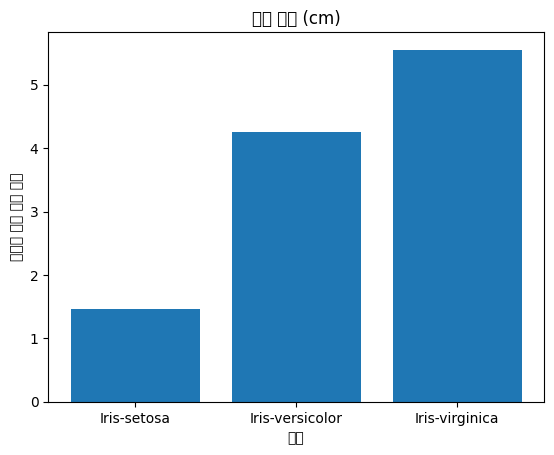

In [73]:
import matplotlib.pyplot as plt
petal_mean = df.groupby("Species")["PetalLengthCm"].mean()
plt.bar(petal_mean.index, petal_mean.values)
plt.title("꽃잎 길이 (cm)")
plt.xlabel("종류")
plt.ylabel("종류별 꽃잎 길이 평균")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44867 (\N{HANGUL SYLLABLE GGOC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51086 (\N{HANGUL SYLLABLE IP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

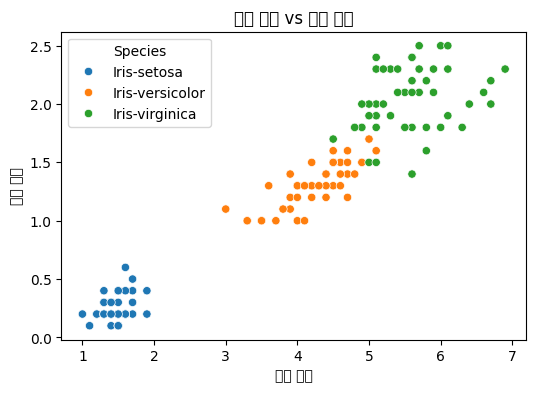

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="PetalLengthCm", y="PetalWidthCm", hue="Species")

plt.title("꽃잎 길이 vs 꽃잎 너비")
plt.xlabel("꽃잎 길이")
plt.ylabel("꽃잎 너비")
plt.show()